<a href="https://colab.research.google.com/github/iceik973-dotcom/ML1/blob/main/%D0%9B%D0%912_1_%D0%93%D1%80%D0%B8%D0%B3%D0%BE%D1%80%D0%B8%D1%88%D0%B5%D0%BD_3_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 2. Григоришен Влад

In [1]:
import numpy
import pandas
import requests

# Завдання 1

**Був присутній на парі**

Обробка та нааліз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

1. Вивести перші 5 рядків датасета

In [2]:
import pandas as pd
import requests

url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"
html = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}).text

tables = pd.read_html(html)
df = tables[2]
df.head()

/tmp/ipykernel_1174/2141660363.py:7: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)


,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


**Висновок:** Завантажено таблицю номінального ВВП країн. Перший рядок містить загальносвітовий показник (World), наступні позиції займають найбільші економіки світу — США та Китай[cite: 3].

In [3]:
df.columns

Index(['Country/Territory', 'IMF (2026)[1]', 'World Bank (2025)[6]',
       'United Nations (2024)[7]'],
      dtype='object')

2.	Визначити розмір датасета.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Country/Territory         222 non-null    object
 1   IMF (2026)[1]             222 non-null    object
 2   World Bank (2025)[6]      222 non-null    object
 3   United Nations (2024)[7]  222 non-null    object
dtypes: object(4)
memory usage: 7.1+ KB


**Висновок:** Датасет містить 222 рядки та 4 стовпці[cite: 3]. Усі стовпці на початковому етапі мають тип даних `object` (текстовий), оскільки числа містять виноски, розділювачі та позначки відсутності даних[cite: 3].

 3.	Визначити оптимальну кількість стовпців (видалити зайві, на власний розсуд).

In [5]:
df.columns = (df.columns
              .str.replace(r'(?:\s*\[\d+\])+', '', regex=True)
              .str.replace('Country/Territory', 'Country', regex=False))
df

,Country,IMF (2026),World Bank (2025),United Nations (2024)
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211
...,...,...,...,...
217,Palau,377,345,310
218,Marshall Islands,342,308,281
219,Nauru,196,176,187
220,Montserrat,—N/a,—N/a,81


In [6]:
df = df.drop(df[df.iloc[:, 0] == "World"].index)

In [7]:
df

,Country,IMF (2026),World Bank (2025),United Nations (2024)
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211
5,United Kingdom,4264794,4002588,3685881
...,...,...,...,...
217,Palau,377,345,310
218,Marshall Islands,342,308,281
219,Nauru,196,176,187
220,Montserrat,—N/a,—N/a,81


**Висновок:** Назви стовпців очищено від посилань та квадратних дужок[cite: 3]. Видалено підсумковий рядок «World», у результаті чого в датасеті залишилася 221 країна та територія[cite: 3].

4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [8]:
df.isnull().sum()

,0
Country,0
IMF (2026),0
World Bank (2025),0
United Nations (2024),0


In [9]:
df['IMF (2026)'] = pd.to_numeric(df['IMF (2026)'], errors='coerce')
df['World Bank (2025)'] = pd.to_numeric(df['World Bank (2025)'], errors='coerce')
df['United Nations (2024)'] = pd.to_numeric(df['United Nations (2024)'], errors='coerce')

In [10]:
df.dtypes

,0
Country,object
IMF (2026),float64
World Bank (2025),float64
United Nations (2024),float64


In [11]:
df

,Country,IMF (2026),World Bank (2025),United Nations (2024)
1,United States,32383920.0,30769700.0,29298000.0
2,China[n 1],20851593.0,19498039.0,18743802.0
3,Germany,5452858.0,5050923.0,4659929.0
4,Japan,4379253.0,4435163.0,4026211.0
5,United Kingdom,4264794.0,4002588.0,3685881.0
...,...,...,...,...
217,Palau,377.0,345.0,310.0
218,Marshall Islands,342.0,308.0,281.0
219,Nauru,196.0,176.0,187.0
220,Montserrat,NaN,NaN,81.0


In [12]:
df.isnull().sum()

,0
Country,0
IMF (2026),31
World Bank (2025),35
United Nations (2024),9


**Висновок:** Після приведення стовпців до числового типу (`float64`) текстові позначки пропусків замінено на `NaN`[cite: 3]. Виявлено пропуски: IMF (2026) — 31, World Bank (2025) — 35, United Nations (2024) — 9[cite: 3].

In [13]:
df.iloc[:, 1:] = df.iloc[:, 1:].apply(lambda x: x.fillna(x.mean()), axis=1)

df.isnull().sum()

,0
Country,0
IMF (2026),8
World Bank (2025),8
United Nations (2024),8


In [14]:
part = df.iloc[:, 1:]

row_filled = part.apply(lambda r: r.fillna(r.mean()), axis=1)
col_means = part.mean()

df.iloc[:, 1:] = row_filled.fillna(col_means)

df.isnull().sum()

,0
Country,0
IMF (2026),0
World Bank (2025),0
United Nations (2024),0


**Висновок:** Пропущені значення заповнено у два етапи: спочатку середнім значенням за наявними роками по кожному рядку, а для країн, де не було жодної оцінки — загальним середнім за стовпцем[cite: 3]. Усі 221 рядок тепер без пропусків[cite: 3].

5. Ще раз вивести датасет

In [15]:
df.tail(10)

,Country,IMF (2026),World Bank (2025),United Nations (2024)
212,Saint Martin,594338.521127,556140.901408,524623.732394
213,Federated States of Micronesia,521.000000,502.000000,471.000000
214,Anguilla,456.000000,456.000000,456.000000
215,Cook Islands,414.000000,414.000000,414.000000
216,Kiribati,401.000000,349.000000,343.000000
217,Palau,377.000000,345.000000,310.000000
218,Marshall Islands,342.000000,308.000000,281.000000
219,Nauru,196.000000,176.000000,187.000000
220,Montserrat,81.000000,81.000000,81.000000
221,Tuvalu,65.000000,57.000000,56.000000


**Висновок:** Перевірка кінця датасету показує успішне відновлення відсутніх даних числовими середніми значеннями[cite: 3]. Найменший ВВП зафіксовано у Тувалу (близько 56–65 млн USD)[cite: 3].

6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [16]:
df.duplicated().sum()

np.int64(0)

**Висновок:** Повних дублікатів рядків у таблиці немає (знайдено 0)[cite: 3].

7.	Вивести описову статистику датасету describe()

In [17]:
df.describe()

,IMF (2026),World Bank (2025),United Nations (2024)
count,2.210000e+02,2.210000e+02,2.210000e+02
mean,5.943385e+05,5.561409e+05,5.246237e+05
std,2.673673e+06,2.527950e+06,2.410273e+06
min,6.500000e+01,5.700000e+01,5.600000e+01
25%,9.442000e+03,9.233000e+03,8.840000e+03
50%,4.884900e+04,4.809900e+04,4.276500e+04
75%,3.773650e+05,3.348550e+05,2.986970e+05
max,3.238392e+07,3.076970e+07,2.929800e+07


**Висновок:** Середній ВВП становить ~550 000–594 000 млн USD[cite: 3], тоді як медіана дорівнює лише ~42 000–48 000 млн USD[cite: 3]. Колосальний розрив між середнім і медіаною та велике стандартне відхилення (~2.5 млн USD) свідчать про екстремальну нерівномірність світової економіки[cite: 3].

8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [18]:
df['IMF_WB_Diff'] = abs(df['IMF (2026)'] - df['World Bank (2025)'])

max_diff = df['IMF_WB_Diff'].max()

country = df[df['IMF_WB_Diff'] == max_diff]['Country'].values[0]
print(f'{country} has the largest difference between IMF and WB: {max_diff}')

df.head(10)

United States has the largest difference between IMF and WB: 1614220.0


,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff
1,United States,32383920.0,30769700.0,29298000.0,1614220.0
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0
3,Germany,5452858.0,5050923.0,4659929.0,401935.0
4,Japan,4379253.0,4435163.0,4026211.0,55910.0
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0
6,India,4153191.0,3956067.0,3952244.0,197124.0
7,France,3596094.0,3366316.0,3160443.0,229778.0
8,Italy,2738164.0,2551557.0,2380825.0,186607.0
9,Russia,2656452.0,2561310.0,2173386.0,95142.0
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0


**Відповідь:** Найбільша абсолютна різниця між оцінками МВФ та Світового банку спостерігається у США — 1 614 220 млн USD[cite: 3]. На другому місці знаходиться Китай із розбіжністю 1 353 554 млн USD[cite: 3]. Це закономірно для найбільших економік планети.

9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?

In [19]:
cor_IMF_WB = df['IMF (2026)'].corr(df['World Bank (2025)'])
cor_IMF_UN = df['IMF (2026)'].corr(df['United Nations (2024)'])
cor_WB_UN = df['World Bank (2025)'].corr(df['United Nations (2024)'])

print(f'Correlation between IMF and WB: {cor_IMF_WB}')
print(f'Correlation between IMF and UN: {cor_IMF_UN}')
print(f'Correlation between  WB and UN: {cor_WB_UN}')

Correlation between IMF and WB: 0.9998772853399375
Correlation between IMF and UN: 0.9998162531253877
Correlation between  WB and UN: 0.9998603541665632


In [20]:
max_cor = max(cor_IMF_WB, cor_IMF_UN, cor_WB_UN)
if max_cor == cor_IMF_WB:
    print('IMF and WB have the highest correlation')
elif max_cor == cor_IMF_UN:
    print('IMF and UN have the highest correlation')
else:
    print('WB and UN have the highest correlation')

IMF and WB have the highest correlation


**Відповідь:** Усі пари показників мають майже ідеальну лінійну кореляцію (> 0.9998)[cite: 3]. Найвища кореляція зафіксована між показниками МВФ та Світового банку (IMF і WB — 0.999877)[cite: 3].

Обчислити середнє значення за стовпцями

In [21]:
mean_IMF = df['IMF (2026)'].mean()
mean_IMF

np.float64(594338.5211267605)

In [22]:
mean_WB = df['World Bank (2025)'].mean()
mean_WB

np.float64(556140.9014084507)

In [23]:
mean_UN = df['United Nations (2024)'].mean()
mean_UN

np.float64(524623.7323943662)

**Висновок:** Середній показник ВВП за роками демонструє плавне зростання: 524 623 млн USD (ООН 2024) -> 556 140 млн USD (СБ 2025) -> 594 338 млн USD (МВФ 2026), що відображає інфляційне та загальне економічне зростання[cite: 3].

11.	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [24]:
df['std'] = df.iloc[:, 1:].std(axis=1)

max_std = df['std'].max()
country = df[df['std'] == max_std]['Country'].values[0]
print(f'{country} has the highest standard deviation: {max_std}')

df.head(10)

United States has the highest standard deviation: 14655779.964896671


,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff,std
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.465578e+07
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,9.213488e+06
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,2.348734e+06
4,Japan,4379253.0,4435163.0,4026211.0,55910.0,2.119895e+06
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0,1.876098e+06
6,India,4153191.0,3956067.0,3952244.0,197124.0,1.913990e+06
7,France,3596094.0,3366316.0,3160443.0,229778.0,1.582291e+06
8,Italy,2738164.0,2551557.0,2380825.0,186607.0,1.194072e+06
9,Russia,2656452.0,2561310.0,2173386.0,95142.0,1.202576e+06
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0,1.024125e+06


**Відповідь:** Найвищу абсолютну варіативність (стандартне відхилення) мають США (std = 14 655 779)[cite: 3], друге місце займає Китай (std = 9 213 488)[cite: 3]. Причиною є гігантський масштаб цих економік, де приріст навіть у кілька відсотків становить трильйони доларів.

12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

In [25]:
max_IMF = df['IMF (2026)'].max(); min_IMF = df['IMF (2026)'].min()
max_WB = df['World Bank (2025)'].max(); min_WB = df['World Bank (2025)'].min()
max_UN = df['United Nations (2024)'].max(); min_UN = df['United Nations (2024)'].min()

print(f'Max IMF: {max_IMF}, Min IMF: {min_IMF}')
print(f'Max WB: {max_WB}, Min WB: {min_WB}')
print(f'Max UN: {max_UN}, Min UN: {min_UN}')

Max IMF: 32383920.0, Min IMF: 65.0
Max WB: 30769700.0, Min WB: 57.0
Max UN: 29298000.0, Min UN: 56.0


**Відповідь:** В усі роки лідером за максимальним ВВП є США (від 29.3 до 32.4 трлн USD)[cite: 3], а країною з найменшим показником є Тувалу (від 56 до 65 млн USD)[cite: 3].

13.	Побудуйте гістограму для розподілу показників IMF (2026) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

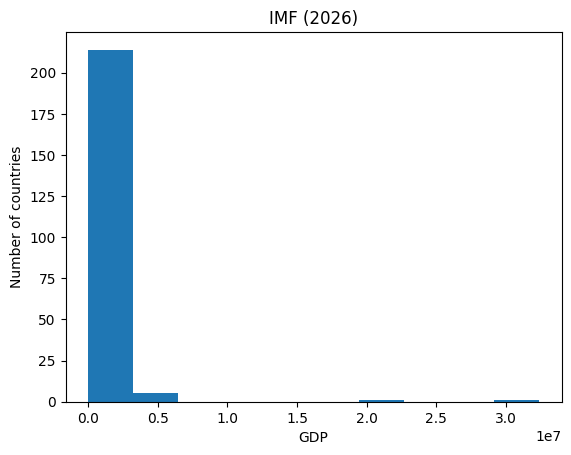

In [26]:
import matplotlib.pyplot as plt

plt.hist(df['IMF (2026)'], bins=10)
plt.title('IMF (2026)')
plt.xlabel('GDP')
plt.ylabel('Number of countries')
plt.show()

**Відповідь:** Розподіл має яскраво виражену правосторонню асиметрію (степеневий характер). Переважна більшість країн зосереджена в першому кошику (ВВП до 3 трлн USD). Яскравими викидами, що виділяються далеко вперед, є США (~32 трлн USD) та Китай (~21 трлн USD)[cite: 3].

14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?

In [27]:
df['IMF_Share'] = df['IMF (2026)'] / df['IMF (2026)'].sum()
df['WB_Share'] = df['World Bank (2025)'] / df['World Bank (2025)'].sum()
df['UN_Share'] = df['United Nations (2024)'] / df['United Nations (2024)'].sum()

df.head(10)

,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff,std,IMF_Share,WB_Share,UN_Share
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.465578e+07,0.246549,0.250349,0.252696
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,9.213488e+06,0.158750,0.158640,0.161666
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,2.348734e+06,0.041514,0.041095,0.040192
4,Japan,4379253.0,4435163.0,4026211.0,55910.0,2.119895e+06,0.033341,0.036085,0.034726
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0,1.876098e+06,0.032469,0.032566,0.031791
6,India,4153191.0,3956067.0,3952244.0,197124.0,1.913990e+06,0.031620,0.032187,0.034088
7,France,3596094.0,3366316.0,3160443.0,229778.0,1.582291e+06,0.027378,0.027389,0.027259
8,Italy,2738164.0,2551557.0,2380825.0,186607.0,1.194072e+06,0.020847,0.020760,0.020535
9,Russia,2656452.0,2561310.0,2173386.0,95142.0,1.202576e+06,0.020224,0.020839,0.018745
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0,1.024125e+06,0.020068,0.018550,0.018853


**Відповідь:** Частки провідних країн є стабільними: США контролюють близько 24.6–25.3% світового ВВП[cite: 3], Китай — близько 15.9–16.2%[cite: 3]. З часом частка США та Китаю в прогнозах МВФ має невелике зниження на користь країн, що розвиваються (наприклад, Індії)[cite: 3].

15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

In [28]:
df['IMF_UN_Diff'] = abs(df['IMF_Share'] - df['UN_Share'])
df_top10 = df.nlargest(10, 'IMF_UN_Diff')
df_top10

,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff,std,IMF_Share,WB_Share,UN_Share,IMF_UN_Diff
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.465578e+07,0.246549,0.250349,0.252696,0.006147
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,9.213488e+06,0.158750,0.158640,0.161666,0.002916
6,India,4153191.0,3956067.0,3952244.0,197124.0,1.913990e+06,0.031620,0.032187,0.034088,0.002469
53,Iran,300293.0,362682.0,448092.0,62389.0,1.654723e+05,0.002286,0.002951,0.003865,0.001579
9,Russia,2656452.0,2561310.0,2173386.0,95142.0,1.202576e+06,0.020224,0.020839,0.018745,0.001479
15,South Korea,1931008.0,1872375.0,1875388.0,58633.0,9.175414e+05,0.014701,0.015234,0.016175,0.001474
4,Japan,4379253.0,4435163.0,4026211.0,55910.0,2.119895e+06,0.033341,0.036085,0.034726,0.001385
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,2.348734e+06,0.041514,0.041095,0.040192,0.001322
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0,1.024125e+06,0.020068,0.018550,0.018853,0.001215
16,Turkey,1640223.0,1597293.0,1323255.0,42930.0,7.518882e+05,0.012488,0.012996,0.011413,0.001074


**Відповідь:** Стабільне номінальне зростання від 2024 до 2026 року демонструють США, Китай, Німеччина та Індія[cite: 3]. Значний спад у прогнозах помітний в Ірану (падіння частки з 0.38% у 2024 році до 0.23% у 2026 році)[cite: 3].

### Загальний висновок по роботі

У ході виконання лабораторної роботи проведено парсинг, передобробку та статистичний аналіз номінального ВВП країн світу за даними трьох міжнародних організацій (МВФ, Світовий банк, ООН):
* **Колосальна концентрація багатства:** Дві провідні наддержави — США та Китай — разом акумулюють понад 40% усього світового ВВП (США ~25%, Китай ~16%)[cite: 3].
* **Узгодженість джерел:** Кореляція між показниками ООН, МВФ та Світового банку перевищує 0.9998, що підтверджує взаємну надійність даних[cite: 3].
* **Нерівномірність розподілу:** Гістограма показує різку правосторонню асиметрію: медіанний ВВП країни складає лише близько 45 млрд USD[cite: 3], тоді як лідери оперують десятками трильйонів доларів[cite: 3].